# 06 - Evaluation & Error Analysis

## AI-Powered Runway FOD Detection & Safety Alert System

### Objective

In the previous notebook, we trained a YOLO object-detection model.

Now we need to answer an important question:

> How well is the detector actually performing?

We will analyze:

- Precision
- Recall
- IoU
- mAP50
- mAP50-95
- Per-class performance
- Confusion matrix
- Detection examples
- False positives
- False negatives
- Confidence scores
- Difficult FOD classes

The goal is not only to obtain a metric, but to understand **where the model
is making mistakes and why**.


## 1. Import Libraries

In [1]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from ultralytics import YOLO


## 2. Project Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "yolo_dataset"
)

DATA_YAML_PATH = DATASET_DIR / "data.yaml"

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "fod_yolo_baseline_best.pt"
)

ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "evaluation"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset:", DATASET_DIR)
print("Model:", MODEL_PATH)
print("Evaluation artifacts:", ARTIFACTS_DIR)


Dataset: d:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset
Model: d:\Projects\AI Runway FOD Detection\models\fod_yolo_baseline_best.pt
Evaluation artifacts: d:\Projects\AI Runway FOD Detection\artifacts\evaluation


## 3. Load the Trained Model

In [3]:
model = YOLO(str(MODEL_PATH))

print("Model loaded successfully.")


Model loaded successfully.


## 4. Run Official Test Evaluation

We will evaluate the model on the official FOD-A test split.

This test set was not used during model training.


In [4]:
test_results = model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=640,
    device=0,
    project=str(ARTIFACTS_DIR),
    name="test_evaluation",
    exist_ok=True
)

print("Test evaluation completed.")


Ultralytics 8.4.174  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 120 layers, 2,380,881 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1.60.6 MB/s, size: 14.8 KB)
val: Scanning D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\test... 8429 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8429/8429 480.2it/s 17.6s0.1s
val: New cache created: D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 527/527 7.3it/s 1:120.2ssss
                   all       8429       8613      0.997      0.993      0.991      0.902
       AdjustableClamp        158        158      0.997      0.994      0.995      0.916
      AdjustableWrench        114        114          1      0.954      0.955       0.89
               Battery        276        276 

## 5. Understand the Main Metrics

### Precision

Precision answers:

> Of the objects predicted by the model, how many were actually correct?

High precision means fewer false positives.

### Recall

Recall answers:

> Of the real FOD objects present, how many did the model detect?

High recall means fewer missed objects.

### IoU

Intersection over Union measures how much the predicted bounding box overlaps
with the ground-truth bounding box.

```text
IoU = Intersection Area / Union Area
```

### mAP50

Mean Average Precision using an IoU threshold of 0.50.

### mAP50-95

Mean Average Precision averaged across IoU thresholds from 0.50 to 0.95.

mAP50-95 is stricter than mAP50.


## 6. Read Overall Metrics

In [5]:
print("Precision:", test_results.box.mp)
print("mAP50:", test_results.box.map50)
print("mAP50-95:", test_results.box.map)

try:
    print("Recall:", test_results.box.mr)
except AttributeError:
    print("Recall is available in the detailed results.")


Precision: 0.9967850245979929
mAP50: 0.990787864618772
mAP50-95: 0.9017882228911971
Recall: 0.9926763850185092


## 7. Per-Class Performance

Overall metrics can hide weak classes.

For example, the model may perform well on:

`Battery`

but poorly on:

`PaintChip`

Per-class evaluation helps us find these problems.


In [6]:
class_names = model.names

per_class_ap50 = test_results.box.ap50
per_class_ap = test_results.box.ap

print("Per-class mAP50")
print()

for class_id, class_name in class_names.items():

    if class_id < len(per_class_ap50):

        print(
            f"{class_id:2d} | "
            f"{class_name:20s} | "
            f"mAP50: {per_class_ap50[class_id]:.4f}"
        )


Per-class mAP50

 0 | AdjustableClamp      | mAP50: 0.9950
 1 | AdjustableWrench     | mAP50: 0.9550
 2 | Battery              | mAP50: 0.9950
 3 | Bolt                 | mAP50: 0.9935
 4 | BoltNutSet           | mAP50: 0.9676
 5 | BoltWasher           | mAP50: 0.9950
 6 | ClampPart            | mAP50: 0.9950
 7 | Cutter               | mAP50: 0.9950
 8 | FuelCap              | mAP50: 0.9950
 9 | Hammer               | mAP50: 0.9950
10 | Hose                 | mAP50: 0.9950
11 | Label                | mAP50: 0.9950
12 | LuggagePart          | mAP50: 0.9950
13 | LuggageTag           | mAP50: 0.9950
14 | MetalPart            | mAP50: 0.9942
15 | MetalSheet           | mAP50: 0.9950
16 | Nail                 | mAP50: 0.9950
17 | Nut                  | mAP50: 0.9950
18 | PaintChip            | mAP50: 0.9950
19 | Pen                  | mAP50: 0.9950
20 | PlasticPart          | mAP50: 0.9950
21 | Pliers               | mAP50: 0.9950
22 | Rock                 | mAP50: 0.9950
23 | Screw       

## 8. Create a Per-Class Performance Table

In [7]:
per_class_rows = []

for class_id, class_name in class_names.items():

    if class_id < len(per_class_ap50):

        per_class_rows.append(
            {
                "class_id": class_id,
                "class_name": class_name,
                "mAP50": per_class_ap50[class_id],
                "mAP50_95": per_class_ap[class_id]
            }
        )

per_class_df = pd.DataFrame(per_class_rows)

per_class_df = per_class_df.sort_values(
    "mAP50",
    ascending=False
)

per_class_df


,class_id,class_name,mAP50,mAP50_95
0,0,AdjustableClamp,0.995000,0.915631
2,2,Battery,0.995000,0.872289
6,6,ClampPart,0.995000,0.933014
5,5,BoltWasher,0.995000,0.841012
9,9,Hammer,0.995000,0.972489
8,8,FuelCap,0.995000,0.912288
7,7,Cutter,0.995000,0.967289
11,11,Label,0.995000,0.919597
12,12,LuggagePart,0.995000,0.983886
13,13,LuggageTag,0.995000,0.871273


## 9. Best Performing Classes

In [8]:
best_classes = per_class_df.head(10)

best_classes


,class_id,class_name,mAP50,mAP50_95
0,0,AdjustableClamp,0.995,0.915631
2,2,Battery,0.995,0.872289
6,6,ClampPart,0.995,0.933014
5,5,BoltWasher,0.995,0.841012
9,9,Hammer,0.995,0.972489
8,8,FuelCap,0.995,0.912288
7,7,Cutter,0.995,0.967289
11,11,Label,0.995,0.919597
12,12,LuggagePart,0.995,0.983886
13,13,LuggageTag,0.995,0.871273


## 10. Weakest Performing Classes

In [9]:
worst_classes = per_class_df.tail(10).sort_values(
    "mAP50"
)

worst_classes


,class_id,class_name,mAP50,mAP50_95
30,30,Wrench,0.944181,0.782942
1,1,AdjustableWrench,0.955000,0.889973
4,4,BoltNutSet,0.967595,0.647281
27,27,Washer,0.985000,0.776830
3,3,Bolt,0.993460,0.816790
14,14,MetalPart,0.994202,0.916580
21,21,Pliers,0.994986,0.933608
29,29,Wood,0.995000,0.987725
23,23,Screw,0.995000,0.874416
22,22,Rock,0.995000,0.886610


## 11. Plot Per-Class mAP50

This makes class imbalance in model performance easier to see.


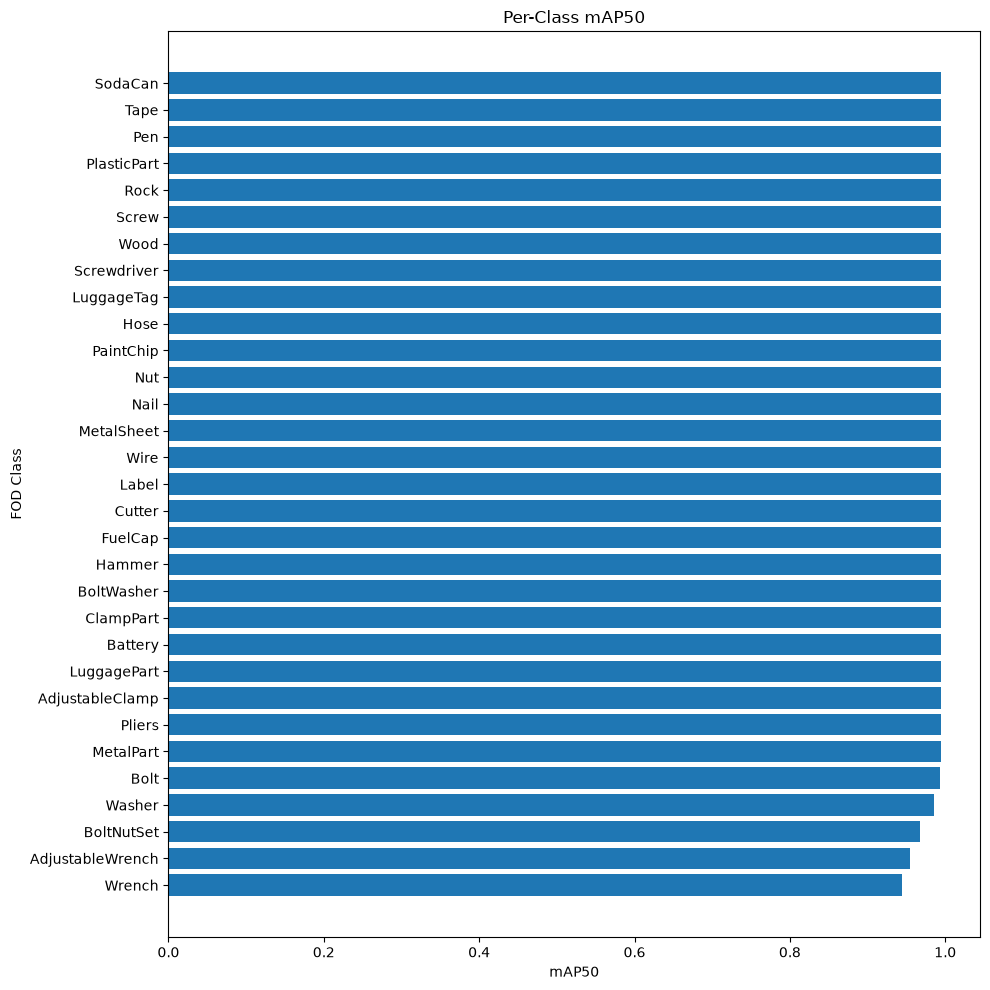

In [10]:
plot_df = per_class_df.sort_values(
    "mAP50",
    ascending=True
)

plt.figure(figsize=(10, 10))

plt.barh(
    plot_df["class_name"],
    plot_df["mAP50"]
)

plt.xlabel("mAP50")
plt.ylabel("FOD Class")
plt.title("Per-Class mAP50")

plt.tight_layout()
plt.show()


## 12. Confusion Matrix

A confusion matrix helps us understand class-level mistakes.

For example, the model may confuse visually similar objects such as:

- Bolt
- Nut
- Washer

This can indicate that the classes have similar visual appearance or that
the available examples are difficult to distinguish.


In [11]:
confusion_results = model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=640,
    device=0,
    plots=True,
    project=str(ARTIFACTS_DIR),
    name="confusion_matrix",
    exist_ok=True
)

print(
    "Confusion matrix plots were generated in:",
    ARTIFACTS_DIR
)


Ultralytics 8.4.174  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 120 layers, 2,380,881 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 151.875.3 MB/s, size: 13.2 KB)
val: Scanning D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\test.cache... 8429 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8429/8429 2.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 527/527 7.5it/s 1:10<0.1sss
                   all       8429       8613      0.997      0.993      0.991      0.902
       AdjustableClamp        158        158      0.997      0.994      0.995      0.916
      AdjustableWrench        114        114          1      0.954      0.955       0.89
               Battery        276        276          1      0.994      0.995      0.872
                  Bolt        832        832       0.99    

## 13. Run Predictions for Error Analysis

Metrics tell us **how much** the model is wrong.

Images help us understand **why** it is wrong.

We will generate predictions on a sample of test images.


In [12]:
test_image_paths = sorted(
    (DATASET_DIR / "images" / "test").glob("*.jpg")
)

sample_test_images = test_image_paths[:20]

prediction_results = model.predict(
    source=[str(path) for path in sample_test_images],
    imgsz=640,
    conf=0.25,
    device=0,
    save=False
)

print("Predictions generated:", len(prediction_results))



0: 640x640 1 Battery, 2.5ms
1: 640x640 1 Battery, 2.5ms
2: 640x640 1 Battery, 2.5ms
3: 640x640 1 Battery, 2.5ms
4: 640x640 1 Battery, 2.5ms
5: 640x640 1 Battery, 2.5ms
6: 640x640 1 Battery, 2.5ms
7: 640x640 1 Battery, 2.5ms
8: 640x640 1 Battery, 2.5ms
9: 640x640 1 Battery, 2.5ms
10: 640x640 1 Battery, 2.5ms
11: 640x640 1 Battery, 2.5ms
12: 640x640 1 Battery, 2.5ms
13: 640x640 1 Battery, 2.5ms
14: 640x640 1 Battery, 2.5ms
15: 640x640 1 Battery, 2.5ms
16: 640x640 1 Battery, 2.5ms
17: 640x640 1 Battery, 2.5ms
18: 640x640 1 Battery, 2.5ms
19: 640x640 1 Battery, 2.5ms
Speed: 1.9ms preprocess, 2.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Predictions generated: 20


## 14. Visualize Test Predictions

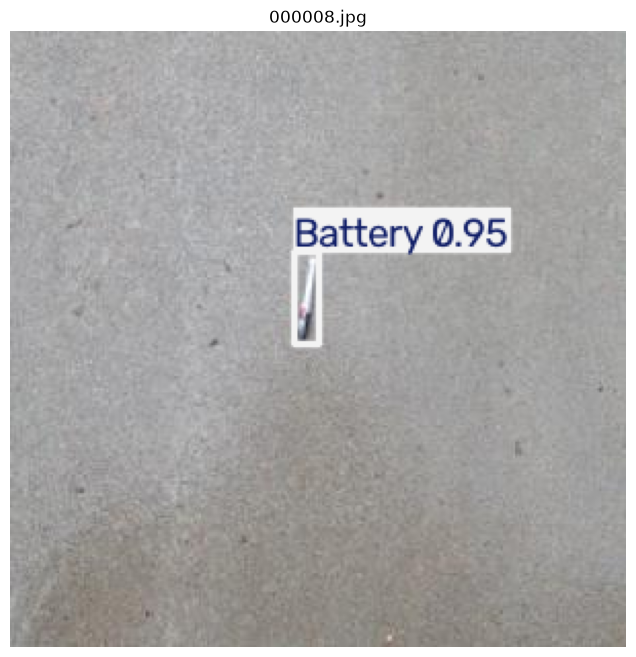

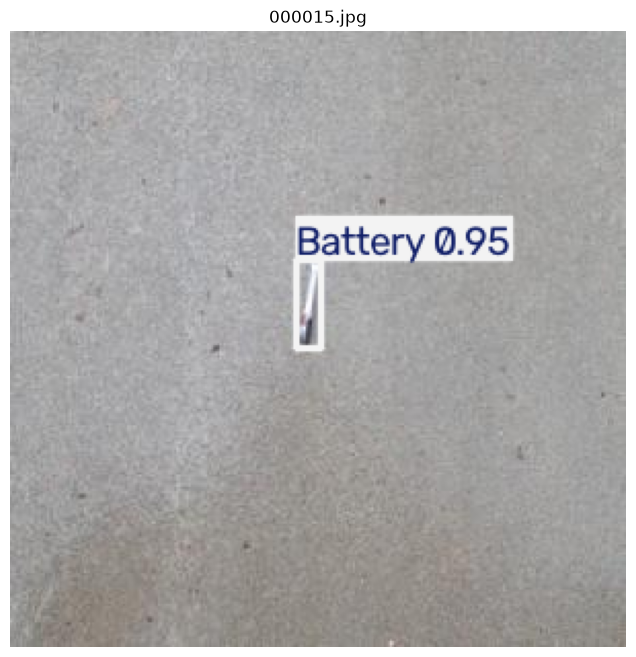

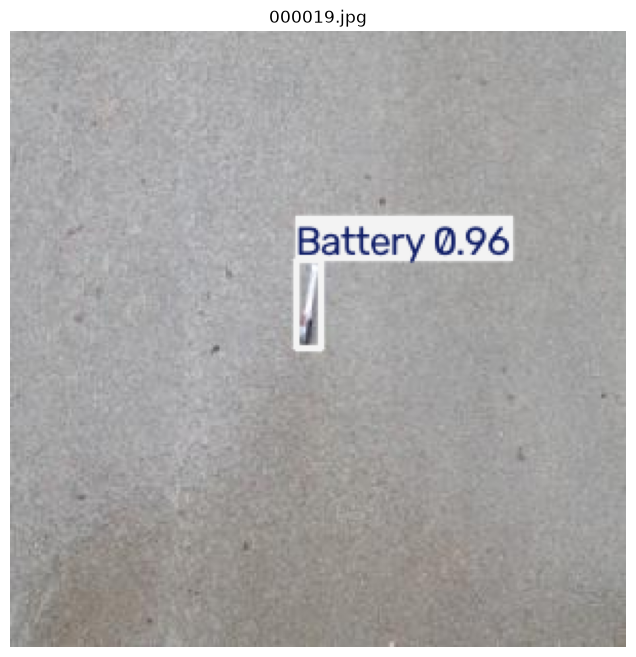

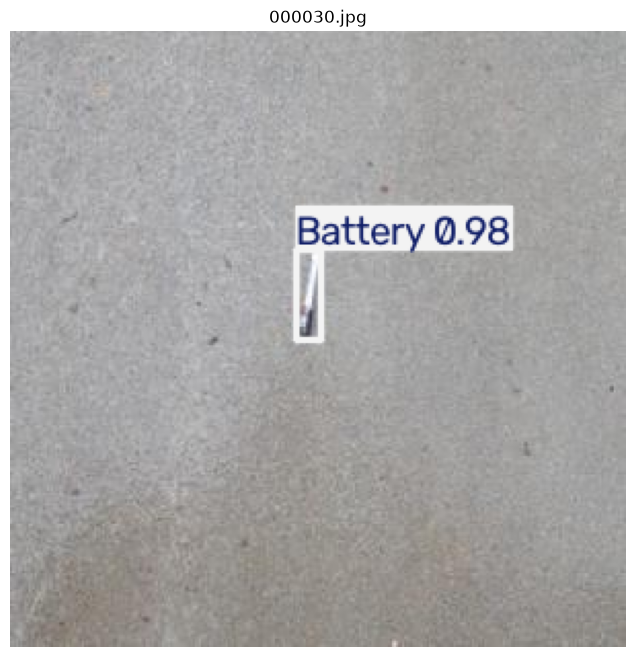

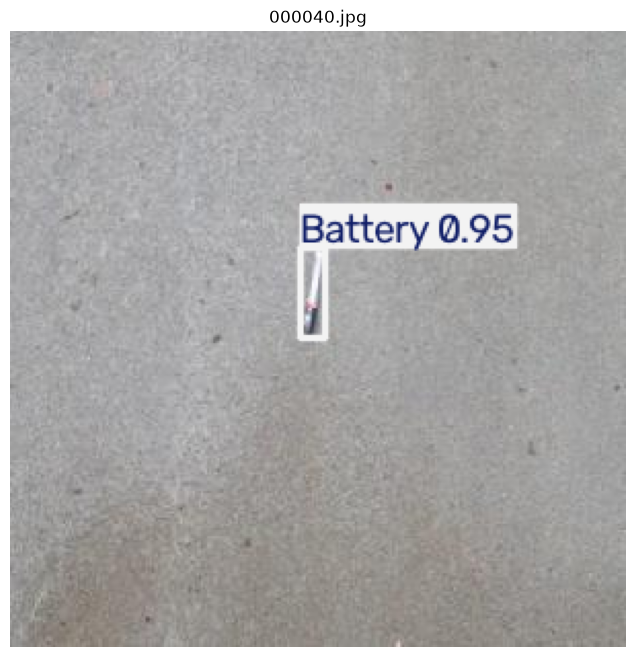

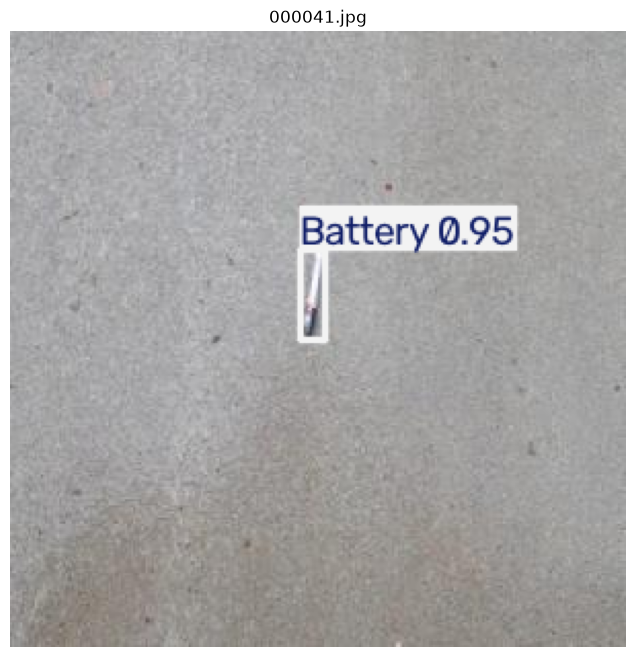

In [13]:
for result in prediction_results[:6]:

    plotted_image = result.plot()

    plt.figure(figsize=(8, 8))

    plt.imshow(
        plotted_image[:, :, ::-1]
    )

    plt.title(
        Path(result.path).name
    )

    plt.axis("off")
    plt.show()


## 15. Inspect Confidence Scores

Every detection has a confidence score.

For example:

```text
Battery → 0.94
Bolt → 0.72
Rock → 0.31
```

A low confidence detection means the model is less certain about the
prediction.


In [14]:
confidence_records = []

for result in prediction_results:

    if result.boxes is None:
        continue

    for index in range(len(result.boxes)):

        class_id = int(
            result.boxes.cls[index].item()
        )

        confidence = float(
            result.boxes.conf[index].item()
        )

        confidence_records.append(
            {
                "image": Path(result.path).name,
                "class_id": class_id,
                "class_name": class_names[class_id],
                "confidence": confidence
            }
        )

confidence_df = pd.DataFrame(
    confidence_records
)

confidence_df.head()


,image,class_id,class_name,confidence
0,000008.jpg,2,Battery,0.951043
1,000015.jpg,2,Battery,0.951418
2,000019.jpg,2,Battery,0.964184
3,000030.jpg,2,Battery,0.975236
4,000040.jpg,2,Battery,0.954500


## 16. Confidence Distribution

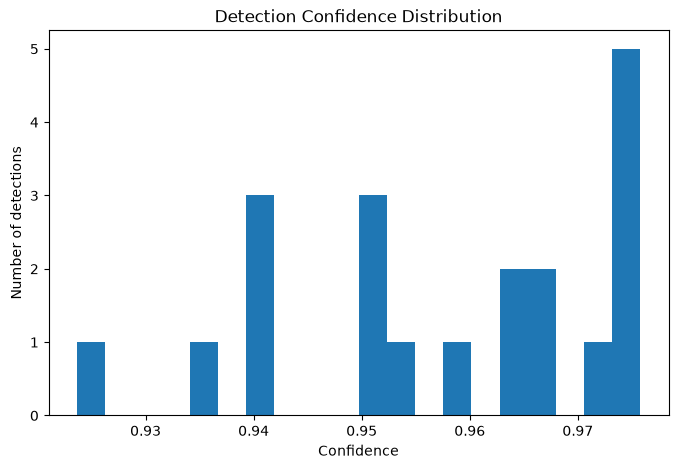

In [15]:
if not confidence_df.empty:

    plt.figure(figsize=(8, 5))

    plt.hist(
        confidence_df["confidence"],
        bins=20
    )

    plt.xlabel("Confidence")
    plt.ylabel("Number of detections")
    plt.title("Detection Confidence Distribution")

    plt.show()


## 17. Compare Confidence Thresholds

A confidence threshold controls which detections are kept.

For example:

```text
conf = 0.25
```

keeps detections with confidence >= 0.25.

Increasing the threshold usually removes more uncertain detections, but it
can also remove real FOD objects.

This creates a precision-recall trade-off.


In [16]:
thresholds = [0.10, 0.25, 0.40, 0.50, 0.60, 0.75]

threshold_results = []

for threshold in thresholds:

    result = model.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=640,
        conf=threshold,
        device=0,
        verbose=False
    )

    threshold_results.append(
        {
            "confidence_threshold": threshold,
            "precision": result.box.mp,
            "recall": result.box.mr,
            "mAP50": result.box.map50,
            "mAP50_95": result.box.map
        }
    )

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df


Ultralytics 8.4.174  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 120 layers, 2,380,881 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 170.173.8 MB/s, size: 10.0 KB)
val: Scanning D:\Projects\AI Runway FOD Detection\data\processed\yolo_dataset\labels\test.cache... 8429 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8429/8429 2.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 527/527 7.5it/s 1:10<0.2sss
                   all       8429       8613      0.998      0.993       0.99      0.901
Speed: 1.0ms preprocess, 2.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to D:\Projects\AI Runway FOD Detection\runs\detect\val-2
Ultralytics 8.4.174  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 120 layers, 2,380,881 parameters, 0 gradi

,confidence_threshold,precision,recall,mAP50,mAP50_95
0,0.10,0.998252,0.992902,0.990490,0.901168
1,0.25,0.998396,0.992921,0.989845,0.901041
2,0.40,0.998454,0.992879,0.989535,0.900888
3,0.50,0.998509,0.992414,0.989212,0.900606
4,0.60,0.998882,0.991703,0.988567,0.899971
5,0.75,0.998965,0.982820,0.979869,0.894493


## 18. Plot Precision and Recall by Threshold

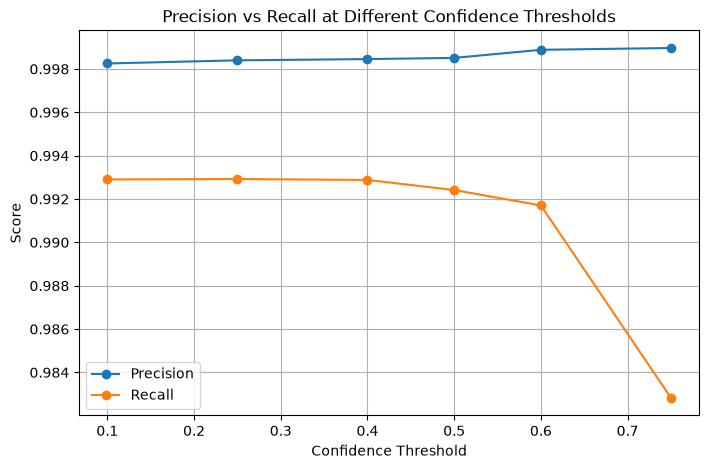

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["confidence_threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["confidence_threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Confidence Thresholds")
plt.legend()
plt.grid(True)

plt.show()


## 19. False Positives and False Negatives

### False Positive

The model predicts FOD, but there is no matching real object.

Example:

```text
Runway surface → model predicts Bolt
Actual image → no Bolt
```

### False Negative

A real FOD object exists, but the model does not detect it.

Example:

```text
Actual → small Screw
Model → no detection
```

For an FOD safety system, false negatives are especially important because
they represent missed debris.


## 20. Analyze Small Objects

FOD objects can be very small relative to the complete runway image.

Small objects are often more difficult to detect.

The annotation analysis notebook already calculated bounding-box size.

Here we inspect the distribution of normalized object areas.


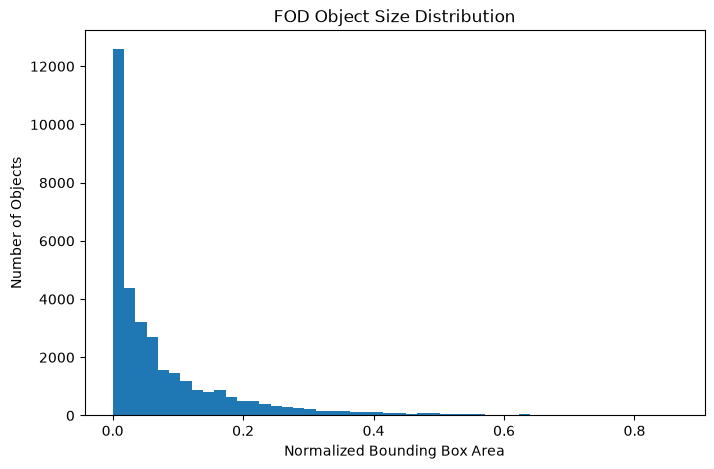

In [18]:
processed_annotations = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "fod_annotations.csv"
)

processed_annotations["bbox_area_ratio"] = (
    processed_annotations["box_width"]
    * processed_annotations["box_height"]
)

plt.figure(figsize=(8, 5))

plt.hist(
    processed_annotations["bbox_area_ratio"],
    bins=50
)

plt.xlabel("Normalized Bounding Box Area")
plt.ylabel("Number of Objects")
plt.title("FOD Object Size Distribution")

plt.show()


## 21. Identify Very Small Objects

This is an exploratory analysis.

A very small normalized bounding box means the object occupies only a small
portion of the complete image.


In [19]:
small_objects = processed_annotations[
    processed_annotations["bbox_area_ratio"] < 0.01
]

print(
    "Very small objects:",
    len(small_objects)
)

print(
    "Percentage:",
    len(small_objects)
    / len(processed_annotations)
    * 100
)


Very small objects: 9057
Percentage: 26.273497331167324


## 22. Analyze Difficult Annotations

The dataset contains annotation metadata such as:

- occluded
- truncated
- difficult

These examples can be useful when explaining difficult model predictions.


In [20]:
difficulty_summary = pd.DataFrame(
    {
        "occluded": [
            int((processed_annotations["occluded"] > 0).sum())
        ],
        "truncated": [
            int((processed_annotations["truncated"] > 0).sum())
        ],
        "difficult": [
            int((processed_annotations["difficult"] > 0).sum())
        ]
    }
)

difficulty_summary


,occluded,truncated,difficult
0,0,0,0


## 23. Save Evaluation Results

We will save the per-class and confidence analysis so that these results can
also be used later by the API/dashboard documentation.


In [21]:
per_class_output = (
    ARTIFACTS_DIR
    / "per_class_metrics.csv"
)

confidence_output = (
    ARTIFACTS_DIR
    / "prediction_confidence.csv"
)

threshold_output = (
    ARTIFACTS_DIR
    / "confidence_threshold_analysis.csv"
)

per_class_df.to_csv(
    per_class_output,
    index=False
)

if not confidence_df.empty:
    confidence_df.to_csv(
        confidence_output,
        index=False
    )

threshold_df.to_csv(
    threshold_output,
    index=False
)

print("Saved:")
print(per_class_output)
print(confidence_output)
print(threshold_output)


Saved:
d:\Projects\AI Runway FOD Detection\artifacts\evaluation\per_class_metrics.csv
d:\Projects\AI Runway FOD Detection\artifacts\evaluation\prediction_confidence.csv
d:\Projects\AI Runway FOD Detection\artifacts\evaluation\confidence_threshold_analysis.csv


## 24. Final Evaluation Summary

At the end of this notebook, we should record:

### Overall performance

- Precision
- Recall
- mAP50
- mAP50-95

### Strong classes

The classes with the highest per-class mAP.

### Weak classes

The classes with the lowest per-class mAP.

### Main error patterns

Examples:

- Small FOD objects
- Visually similar FOD classes
- Occluded objects
- Low-confidence detections
- Missed objects
- False positives

### Operational consideration

For a safety-oriented FOD system, maximizing a single metric is not enough.
The model's missed detections and confidence behavior must also be examined.


## 25. Project Status After Evaluation

The machine-learning workflow is now:

```text
FOD-A Dataset
      ↓
EDA
      ↓
Annotation Analysis
      ↓
Image Preprocessing
      ↓
CNN Classification Baseline
      ↓
YOLO Object Detection
      ↓
Evaluation
      ↓
Error Analysis
```

The next phase is engineering the trained detector into the application:

```text
YOLO Model
    ↓
FastAPI
    ↓
Image Upload
    ↓
Prediction
    ↓
Bounding Boxes
    ↓
FOD Class
    ↓
Confidence
    ↓
Safety Alert / Result Dashboard
```

This turns the notebook experiment into an end-to-end computer-vision
application.
